# Исследовательский анализ данных сервиса Яндекс Афиша

# Цель проекта

Провести исследовательский анализ данных сервиса Яндекс Афиша, выявить изменения пользовательского спроса осенью 2024 года, определить наиболее популярные категории мероприятий, оценить пользовательскую активность, а также проверить статистические гипотезы о различиях между пользователями мобильных и стационарных устройств.

# Задачи проекта

- Загрузить и изучить данные.
- Выполнить предобработку данных.
- Подготовить данные к исследованию.
- Проанализировать изменение пользовательского спроса.
- Исследовать сезонные изменения заказов.
- Оценить пользовательскую активность.
- Определить наиболее популярные мероприятия, регионы и билетных операторов.
- Проверить статистические гипотезы.
- Сформулировать выводы и рекомендации.

# Описание датасетов

Использованы данные о заказах билетов, мероприятиях и валютных курсах
за период с июня по октябрь 2024 года.

Исходные датасеты не публикуются в соответствии с условиями
использования учебных материалов Яндекс Практикума.

# Содержание проекта

- [1. Загрузка данных и знакомство с ними](#step-1)
- [2. Предобработка данных и подготовка их к исследованию](#step-2)
    - [2.1 Проверка пропусков](#step-2-1)
    - [2.2 Изучение категориальных значений](#step-2-2)
    - [2.3 Исследование количественных признаков](#step-2-3)
    - [2.4 Проверка дубликатов](#step-2-4)
    - [2.5 Преобразование типов данных](#step-2-5)
    - [2.6 Объединение данных и создание новых столбцов](#step-2-6)
    - [2.7 Проверка заказов без информации о мероприятии](#step-2-7)
    - [2.8 Создание новых признаков](#step-2-8)
- [3. Исследовательский анализ данных](#step-3)
    - [3.1 Анализ распределения заказов по сегментам и их сезонные изменения](#step-3-1)
    - [3.2 Анализ распределения заказов по типам мероприятий](#step-3-2)
    - [3.3 Анализ распределения заказов по типам устройств](#step-3-3)
    - [3.4 Анализ распределения заказов по возрастным ограничениям](#step-3-4)
    - [3.5 Анализ средней выручки с продажи одного билета по типам мероприятий](#step-3-5)
    - [3.6 Осенняя активность пользователей](#step-3-6)
    - [3.7 Анализ недельной цикличности](#step-3-7)
    - [3.8 Популярные события и партнёры](#step-3-8)
    - [3.9 Анализ билетных операторов](#step-3-9)
- [4. Статистический анализ данных](#step-4)
    - [4.1 Изучение данных для проверки первой гипотезы](#step-4-1)
    - [4.2 Проверка первой гипотезы](#step-4-2)
    - [4.3 Изучение данных для проверки второй гипотезы](#step-4-3)
    - [4.4 Проверка второй гипотезы](#step-4-4)
- [5. Общий вывод и рекомендации](#step-5)

<a id="step-1"></a>
## Загрузка данных и знакомство с ними 

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Настраиваем отображение таблиц
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [3]:
# Загружаем датасет с заказами
orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')

In [4]:
# Загружаем датасет с мероприятиями
events = pd.read_csv('/datasets/final_tickets_events_df.csv')

In [5]:
# Загружаем датасет с курсом тенге
tenge = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

In [6]:
# Выводим первые строки датасета с заказами
orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [7]:
# Получаем общую информацию о датасете с заказами
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [8]:
# Выводим первые строки датасета с мероприятиями
events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [9]:
# Получаем общую информацию о датасете с мероприятиями
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [10]:
# Выводим первые строки датасета с курсом валют
tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [11]:
# Получаем общую информацию о датасете с курсом валют
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Данные успешно загружены, структура всех трёх датасетов соответствует описанию проекта.

Датасет `orders` содержит **290 849** записей и **14** столбцов. Пропуски обнаружены только в столбце `days_since_prev` (268 909 непустых значений), что соответствует описанию данных: для пользователей без предыдущих покупок значение отсутствует. Остальные столбцы заполнены полностью. Типы данных в целом корректны, однако столбцы `created_dt_msk` и `created_ts_msk` имеют тип `object` и в дальнейшем потребуют преобразования в формат даты и времени.

Датасет `events` содержит **22 427** записей и **11** столбцов. Пропусков не обнаружено. Типы данных соответствуют содержимому столбцов: идентификаторы имеют числовой тип, текстовые характеристики — строковый.

Датасет `tenge` содержит **357** записей и **4** столбца. Пропусков также не выявлено. Столбец `data` хранится в формате `object` и потребует преобразования к типу даты перед объединением с основным датасетом.

На данном этапе критических проблем в данных не обнаружено. Далее необходимо проверить данные на пропуски, корректность значений, наличие выбросов и дубликатов, а также подготовить их к дальнейшему исследованию.

<a id="step-2"></a>
## Предобработка данных и подготовка их к исследованию
<a id="step-2-1"></a>
### Проверка пропусков

In [12]:
# Подсчитываем количество пропусков в каждом столбце датасета с заказами
orders.isna().sum()

order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

In [13]:
# Рассчитываем долю пропусков в каждом столбце датасета с заказами
orders.isna().mean().mul(100).round(2)

order_id                 0.00
user_id                  0.00
created_dt_msk           0.00
created_ts_msk           0.00
event_id                 0.00
cinema_circuit           0.00
age_limit                0.00
currency_code            0.00
device_type_canonical    0.00
revenue                  0.00
service_name             0.00
tickets_count            0.00
total                    0.00
days_since_prev          7.54
dtype: float64

Проверка показала, что пропуски присутствуют только в столбце `days_since_prev` датасета `orders` — **21 940** значений (**7,54%**). Это соответствует описанию данных: пропуск означает, что пользователь совершил первую покупку и предыдущего заказа у него не было.

В остальных столбцах датасета `orders` пропусков не обнаружено.

При изучении структуры датасетов на предыдущем этапе было установлено, что в датасетах `events` и `tenge` пропуски отсутствуют, поэтому дополнительная проверка для них не требуется.

<a id="step-2-2"></a>
### Изучение категориальных значений

In [14]:
# Просматриваем уникальные значения в столбце с валютой оплаты
orders['currency_code'].value_counts(dropna=False)

rub    285780
kzt      5069
Name: currency_code, dtype: int64

In [15]:
# Просматриваем уникальные значения в столбце с типом устройства
orders['device_type_canonical'].value_counts(dropna=False)

mobile     232679
desktop     58170
Name: device_type_canonical, dtype: int64

In [16]:
# Просматриваем уникальные значения в столбце с сетью кинотеатров
orders['cinema_circuit'].value_counts(dropna=False)

нет           289451
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64

In [17]:
# Просматриваем уникальные значения в столбце с возрастными ограничениями
orders['age_limit'].value_counts(dropna=False).sort_index()

0     61487
6     52173
12    62557
16    78579
18    36053
Name: age_limit, dtype: int64

In [18]:
# Просматриваем уникальные значения в столбце с основным типом мероприятия
events['event_type_main'].value_counts(dropna=False)

концерты    8680
театр       7076
другое      4658
спорт        872
стендап      636
выставки     290
ёлки         215
Name: event_type_main, dtype: int64

In [19]:
# Проверяем количество уникальных билетных операторов
orders['service_name'].nunique()

36

In [20]:
# Проверяем количество уникальных регионов
events['region_name'].nunique()

81

In [21]:
# Проверяем количество уникальных городов
events['city_name'].nunique()

352

Изучение категориальных признаков показало, что данные выглядят корректно.

В столбце `currency_code` присутствуют только две валюты оплаты — `rub` и `kzt`, что соответствует описанию данных. В столбце `device_type_canonical` представлены два типа устройств — `mobile` и `desktop`.

Столбец `cinema_circuit` содержит названия сетей кинотеатров, при этом большинство заказов относится к значению `'нет'`, что означает отсутствие сети кинотеатров для данного мероприятия и не является пропуском.

Возрастные ограничения представлены допустимыми категориями: 0, 6, 12, 16 и 18 лет. В датасете с мероприятиями присутствуют семь основных категорий мероприятий: концерты, театр, другое, спорт, стендап, выставки и ёлки.

Также установлено, что данные содержат **36** билетных операторов, **81** регион и **352** города.

Некорректных категорий, скрытых пропусков или значений, требующих нормализации, на данном этапе не обнаружено.

<a id="step-2-3"></a>
###  Исследование количественных признаков

In [22]:
# Разделяем данные по валюте оплаты
orders_rub = orders[orders['currency_code'] == 'rub']
orders_kzt = orders[orders['currency_code'] == 'kzt']

In [23]:
# Выводим статистические показатели выручки в рублях
orders_rub['revenue'].describe()

count    285780.000000
mean        547.568333
std         871.524559
min         -90.760000
25%         113.827500
50%         346.100000
75%         791.700000
max       81174.540000
Name: revenue, dtype: float64

In [24]:
# Выводим статистические показатели выручки в тенге
orders_kzt['revenue'].describe()

count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64

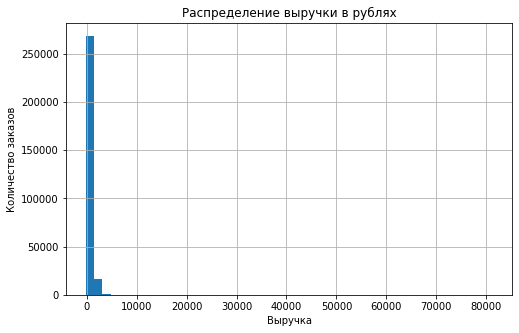

In [25]:
# Строим гистограмму распределения выручки в рублях
orders_rub['revenue'].hist(bins=50, figsize=(8, 5))
plt.title('Распределение выручки в рублях')
plt.xlabel('Выручка')
plt.ylabel('Количество заказов')
plt.show()

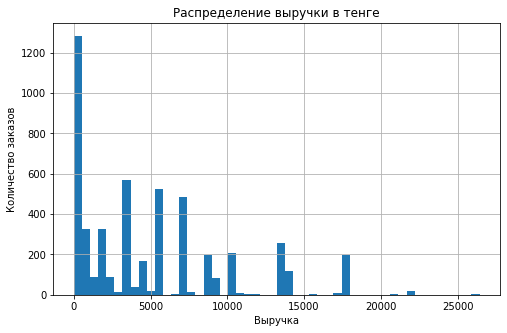

In [26]:
# Строим гистограмму распределения выручки в тенге
orders_kzt['revenue'].hist(bins=50, figsize=(8, 5))
plt.title('Распределение выручки в тенге')
plt.xlabel('Выручка')
plt.ylabel('Количество заказов')
plt.show()

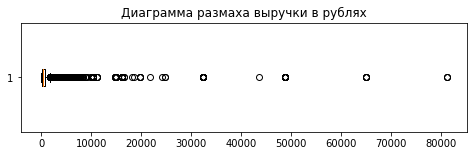

In [27]:
# Строим диаграмму размаха для выручки в рублях
plt.figure(figsize=(8, 2))
plt.boxplot(orders_rub['revenue'], vert=False)
plt.title('Диаграмма размаха выручки в рублях')
plt.show()

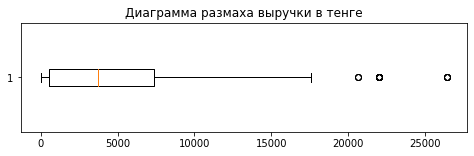

In [28]:
# Строим диаграмму размаха для выручки в тенге
plt.figure(figsize=(8, 2))
plt.boxplot(orders_kzt['revenue'], vert=False)
plt.title('Диаграмма размаха выручки в тенге')
plt.show()

In [29]:
# Выводим статистические показатели количества билетов в заказе
orders['tickets_count'].describe()

count    290849.000000
mean          2.754230
std           1.170467
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

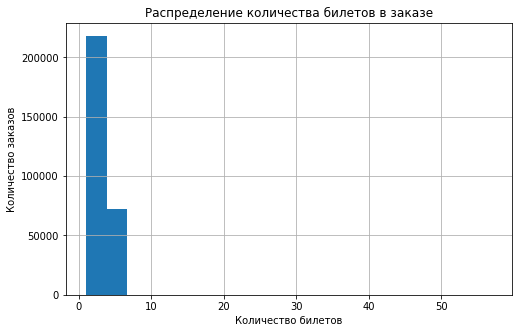

In [30]:
# Строим гистограмму распределения количества билетов
orders['tickets_count'].hist(bins=20, figsize=(8, 5))
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')
plt.ylabel('Количество заказов')
plt.show()

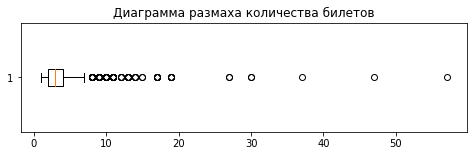

In [31]:
# Строим диаграмму размаха для количества билетов
plt.figure(figsize=(8, 2))
plt.boxplot(orders['tickets_count'], vert=False)
plt.title('Диаграмма размаха количества билетов')
plt.show()

In [32]:
# Рассчитываем 99-й процентиль выручки в рублях
revenue_rub_99 = orders.loc[orders['currency_code'] == 'rub','revenue'].quantile(0.99)

In [33]:
# Рассчитываем 99-й процентиль выручки в тенге
revenue_kzt_99 = orders.loc[orders['currency_code'] == 'kzt','revenue'].quantile(0.99)

In [34]:
# Сохраняем количество заказов по каждой валюте до фильтрации
rub_before = len(orders[orders['currency_code'] == 'rub'])
kzt_before = len(orders[orders['currency_code'] == 'kzt'])

In [35]:
# Оставляем заказы с выручкой не выше 99-го процентиля
orders = orders[
    ((orders['currency_code'] == 'rub') & (orders['revenue'] <= revenue_rub_99)) |
    ((orders['currency_code'] == 'kzt') & (orders['revenue'] <= revenue_kzt_99))]

In [36]:
# Подсчитываем количество заказов по каждой валюте после фильтрации
rub_after = len(orders[orders['currency_code'] == 'rub'])
kzt_after = len(orders[orders['currency_code'] == 'kzt'])

In [37]:
# Выводим количество удалённых заказов
print(f'Удалено заказов в рублях: {rub_before - rub_after}')
print(f'Удалено заказов в тенге: {kzt_before - kzt_after}')
print(f'Всего удалено заказов: {(rub_before - rub_after) + (kzt_before - kzt_after)}')

Удалено заказов в рублях: 2858
Удалено заказов в тенге: 29
Всего удалено заказов: 2887


Анализ количественных признаков показал, что распределение выручки как в рублях, так и в тенге имеет выраженную правостороннюю асимметрию. Основная часть заказов характеризуется относительно небольшой стоимостью, однако в данных присутствуют отдельные экстремально высокие значения.

Для снижения влияния выбросов была выполнена фильтрация по 99-му процентилю отдельно для каждой валюты. В результате исключено **2 858** заказов в рублях и **29** заказов в тенге, всего — **2 887** записей (около **0,99%** исходного объёма данных). Таким образом, основная часть данных была сохранена.

Распределение количества билетов в заказе также имеет правостороннюю асимметрию. Наиболее часто пользователи приобретают от двух до четырёх билетов, при этом встречаются единичные крупные заказы.

<a id="step-2-4"></a>
### Проверка дубликатов

In [38]:
# Проверяем наличие явных дубликатов в датасете с заказами
orders.duplicated().sum()

0

In [39]:
# Проверяем наличие явных дубликатов в датасете с мероприятиями
events.duplicated().sum()

0

In [40]:
# Проверяем наличие явных дубликатов в датасете с курсами валют
tenge.duplicated().sum()

0

Явные дубликаты отсутствуют во всех трёх датасетах. Далее необходимо проверить наличие неявных дубликатов, которые могут возникнуть при повторном бронировании одного и того же мероприятия.

In [41]:
# Проверяем наличие неявных дубликатов без учёта идентификатора заказа
orders.duplicated(subset=orders.columns.drop('order_id')).sum()

30

In [42]:
# Сохраняем идентификаторы неявных дубликатов
duplicate_orders = orders[
    orders.duplicated(subset=orders.columns.drop('order_id'), keep=False)].sort_values(by=['user_id', 'created_ts_msk'])

In [43]:
# Выводим первые строки найденных неявных дубликатов
duplicate_orders.head(15)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,Билеты в руки,1,997.48,0.0
57217,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
57220,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,Лови билет!,2,280.81,0.0
84010,3363711,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0
84015,3363798,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,Билеты в руки,3,739.85,0.0
148473,2324032,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0
148477,2323916,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,Лучшие билеты,4,674.12,0.0
154170,5372628,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0
154173,5372831,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,Билеты без проблем,1,3170.95,0.0


In [44]:
# Удаляем неявные дубликаты, сохраняя первую запись
orders = orders.drop_duplicates(subset=orders.columns.drop('order_id'),keep='first')

In [45]:
# Проверяем, что неявные дубликаты удалены
orders.duplicated(subset=orders.columns.drop('order_id')).sum()

0

При проверке данных обнаружено **30** неявных дубликатов. Анализ показал, что записи отличаются только значением `order_id`, тогда как остальные признаки полностью совпадают, включая пользователя, дату и время заказа, мероприятие, стоимость, количество билетов и другие характеристики.

Поскольку такие записи могут привести к завышению числа заказов и финансовых показателей, они были удалены, оставив по одному экземпляру каждой записи.

<a id="step-2-5"></a>
### Преобразование типов данных

In [46]:
# Преобразуем столбец с датой оформления заказа в формат datetime
orders['created_dt_msk'] = pd.to_datetime(orders['created_dt_msk'])

In [47]:
# Преобразуем столбец с датой и временем оформления заказа в формат datetime
orders['created_ts_msk'] = pd.to_datetime(orders['created_ts_msk'])

In [48]:
# Преобразуем столбец с датой курса валют в формат datetime
tenge['data'] = pd.to_datetime(tenge['data'])

In [49]:
# Снижаем размерность целочисленных столбцов
for column in orders.select_dtypes(include='int').columns:
    orders[column] = pd.to_numeric(orders[column], downcast='integer')

In [50]:
# Снижаем размерность вещественных столбцов
for column in orders.select_dtypes(include='float').columns:
    orders[column] = pd.to_numeric(orders[column], downcast='float')

In [51]:
# Снижаем размерность целочисленных столбцов
for column in events.select_dtypes(include='int').columns:
    events[column] = pd.to_numeric(events[column], downcast='integer')

In [52]:
# Снижаем размерность вещественных столбцов
for column in tenge.select_dtypes(include='float').columns:
    tenge[column] = pd.to_numeric(tenge[column], downcast='float')

In [53]:
# Возвращаем денежным показателям повышенную точность
orders['revenue'] = orders['revenue'].astype('float64')
orders['total'] = orders['total'].astype('float64')
tenge['curs'] = tenge['curs'].astype('float64')

In [54]:
# Снижаем размерность номинала валюты
tenge['nominal'] = pd.to_numeric(tenge['nominal'], downcast='integer')

In [55]:
# Проверяем типы данных в датафрейме orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287932 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               287932 non-null  int32         
 1   user_id                287932 non-null  object        
 2   created_dt_msk         287932 non-null  datetime64[ns]
 3   created_ts_msk         287932 non-null  datetime64[ns]
 4   event_id               287932 non-null  int32         
 5   cinema_circuit         287932 non-null  object        
 6   age_limit              287932 non-null  int8          
 7   currency_code          287932 non-null  object        
 8   device_type_canonical  287932 non-null  object        
 9   revenue                287932 non-null  float64       
 10  service_name           287932 non-null  object        
 11  tickets_count          287932 non-null  int8          
 12  total                  287932 non-null  floa

In [56]:
# Проверяем типы данных в датафрейме events
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int32 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int32 
 8   venue_id                22427 non-null  int16 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int16(1), int32(2), object(8)
memory usage: 1.6+ MB


In [57]:
# Проверяем типы данных в датафрейме tenge
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[ns]
 1   nominal  357 non-null    int8          
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    object        
dtypes: datetime64[ns](1), float64(1), int8(1), object(1)
memory usage: 8.8+ KB


Столбцы с датами и временем были преобразованы в формат `datetime`. Для числовых столбцов выполнено снижение размерности типов данных без потери значимой точности.

Денежные показатели `revenue` и `total`, а также курс валюты `curs` сохранены в формате `float64`, поскольку они используются в финансовых расчётах.

<a id="step-2-6"></a>
### Объединение данных и создание новых столбцов

In [58]:
# Объединяем датасет с заказами и датасет с мероприятиями
data = orders.merge(events,on='event_id',how='left')

In [59]:
# Проверяем размер объединённого датафрейма
data.shape

(287932, 24)

In [60]:
# Проверяем, появились ли пропуски после объединения
data.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21733
event_name                  238
event_type_description      238
event_type_main             238
organizers                  238
region_name                 238
city_name                   238
city_id                     238
venue_id                    238
venue_name                  238
venue_address               238
dtype: int64

<a id="step-2-7"></a>
### Проверка заказов без информации о мероприятии

In [61]:
# Просматриваем заказы, для которых не нашлось информации о мероприятии
data[data['event_name'].isna()].head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
62,6493246,002ec276eee9b0b,2024-10-14,2024-10-14 16:27:53,533222,нет,6,rub,mobile,78.750000,Билеты в руки,2,787.450012,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,6493275,002ec276eee9b0b,2024-10-14,2024-10-14 16:22:38,533222,нет,6,rub,mobile,78.750000,Билеты в руки,2,787.450012,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,6493304,002ec276eee9b0b,2024-10-14,2024-10-14 16:29:20,533222,нет,6,rub,mobile,118.120003,Билеты в руки,3,1181.180054,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
234,8272280,00da083909dc06b,2024-06-07,2024-06-07 17:50:50,530296,нет,18,rub,mobile,0.000000,Билеты без проблем,4,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
235,8272512,00da083909dc06b,2024-06-07,2024-06-07 17:49:16,530296,нет,18,rub,mobile,0.000000,Билеты без проблем,1,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
# Проверяем количество уникальных мероприятий без информации
data.loc[data['event_name'].isna(), 'event_id'].nunique()

19

In [63]:
# Выводим идентификаторы отсутствующих мероприятий
data.loc[data['event_name'].isna(), 'event_id'].unique()

array([533222, 530296, 532300, 477731, 536716, 246804, 536731, 555671,
       548224, 538260, 534151, 536715, 539336, 553041, 553435, 548062,
       572020, 559840, 505937], dtype=int32)

После объединения датасетов количество записей не изменилось, что подтверждает корректность операции объединения.

При этом было обнаружено **238 заказов**, относящихся к **19 мероприятиям**, информация о которых отсутствует в датасете с мероприятиями. Поскольку для этих записей невозможно определить тип мероприятия, регион, город и площадку проведения, они не могут быть использованы в дальнейшем исследовании и будут исключены из анализа.

In [64]:
# Удаляем заказы без информации о мероприятии
data = data.dropna(subset=['event_name'])

In [65]:
# Проверяем размер датафрейма после удаления записей
data.shape

(287694, 24)

In [66]:
# Проверяем, что пропуски в информации о мероприятиях отсутствуют
data.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21706
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
dtype: int64

<a id="step-2-8"></a>
### Создание новых признаков

In [67]:
# Объединяем данные с курсом тенге по дате заказа
data = data.merge(tenge[['data', 'curs']],left_on='created_dt_msk',right_on='data',how='left')

In [68]:
# Проверяем результат объединения с курсом валют
data[['created_dt_msk', 'currency_code', 'curs']].head()

,created_dt_msk,currency_code,curs
0,2024-08-20,rub,18.697201
1,2024-07-23,rub,18.341900
2,2024-10-06,rub,19.647499
3,2024-07-13,rub,18.500999
4,2024-10-04,rub,19.664801


In [69]:
# Создаём столбец с выручкой, приведённой к рублям
data['revenue_rub'] = np.where(data['currency_code'] == 'rub',data['revenue'],data['revenue'] * data['curs'] / 100)

In [70]:
# Проверяем первые строки нового столбца
data[['currency_code', 'revenue', 'curs', 'revenue_rub']].head()

,currency_code,revenue,curs,revenue_rub
0,rub,1521.939941,18.697201,1521.939941
1,rub,289.450012,18.341900,289.450012
2,rub,1258.569946,19.647499,1258.569946
3,rub,8.490000,18.500999,8.490000
4,rub,1390.410034,19.664801,1390.410034


In [71]:
# Рассчитываем выручку с продажи одного билета в рублях
data['one_ticket_revenue_rub'] = (data['revenue_rub'] / data['tickets_count'])

In [72]:
# Выделяем месяц оформления заказа
data['month'] = data['created_dt_msk'].dt.month

In [73]:
# Создаём функцию для определения сезона
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'

In [74]:
# Создаём столбец с сезоном оформления заказа
data['season'] = data['month'].apply(get_season)

In [75]:
# Проверяем первые строки созданных столбцов
data[['revenue_rub','one_ticket_revenue_rub','month','season']].head()

,revenue_rub,one_ticket_revenue_rub,month,season
0,1521.939941,380.484985,8,лето
1,289.450012,144.725006,7,лето
2,1258.569946,314.642487,10,осень
3,8.490000,4.245000,7,лето
4,1390.410034,463.470011,10,осень


In [76]:
# Проверяем распределение заказов по сезонам
data['season'].value_counts()

осень    168585
лето     119109
Name: season, dtype: int64

В ходе предобработки данные были проверены на пропуски, некорректные категории, выбросы и дубликаты.

Пропуски обнаружены только в столбце `days_since_prev`, где они соответствуют отсутствию предыдущей покупки. После объединения заказов с данными о мероприятиях были исключены 238 заказов, относящихся к 19 мероприятиям, отсутствующим в справочнике событий.

Для снижения влияния экстремальных значений была выполнена фильтрация выручки по 99-му процентилю отдельно для рублей и тенге. Исключено 2 887 заказов, что составляет около 0,99% исходного объёма данных.

Также были удалены 30 неявных дубликатов, отличавшихся только идентификатором заказа.

Столбцы с датами приведены к формату `datetime`, а размерность числовых типов данных была снижена без потери значимой точности.

Для дальнейшего анализа созданы новые признаки:

- `revenue_rub` — выручка заказа, приведённая к российским рублям;
- `one_ticket_revenue_rub` — выручка с продажи одного билета;
- `month` — месяц оформления заказа;
- `season` — сезон оформления заказа.

После завершения предобработки итоговый датасет содержит 287 694 записи и готов к исследовательскому анализу.

<a id="step-3"></a>
## Исследовательский анализ данных
<a id="step-3-1"></a>
### Анализ распределения заказов по сегментам и их сезонные изменения

In [77]:
# Рассчитываем количество заказов по месяцам
orders_by_month = (data.groupby('month').agg(orders_count=('order_id', 'count')).reset_index())
orders_by_month

,month,orders_count
0,6,34164
1,7,40404
2,8,44541
3,9,69322
4,10,99263


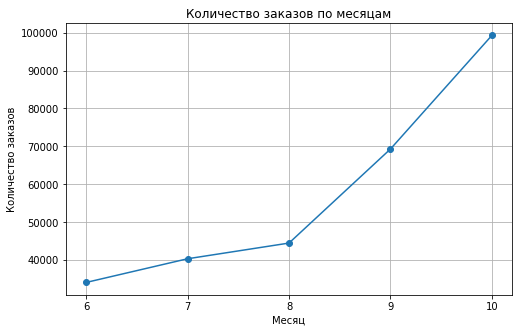

In [78]:
# Строим график количества заказов по месяцам
plt.figure(figsize=(8, 5))

plt.plot(
    orders_by_month['month'],
    orders_by_month['orders_count'],
    marker='o'
)

plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.xticks(orders_by_month['month'])

plt.grid(True)

plt.show()

Анализ динамики количества заказов показал устойчивый рост пользовательской активности на протяжении всего исследуемого периода. Если в июне было оформлено 34 164 заказа, то к октябрю их количество увеличилось до 99 263.

Наиболее заметный прирост наблюдается с сентября, а максимальное количество заказов приходится на октябрь. Полученные результаты подтверждают вывод, сделанный на этапе построения дашборда, о значительном увеличении пользовательского спроса с наступлением осени.

<a id="step-3-2"></a>
### Анализ распределения заказов по типам мероприятий

In [79]:
# Рассчитываем количество заказов по сезонам и типам мероприятий
event_type_share = (data.groupby(['season', 'event_type_main']).agg(orders_count=('order_id', 'count')).reset_index())

In [80]:
# Рассчитываем долю каждого типа мероприятия внутри сезона
event_type_share['share'] = (event_type_share.groupby('season')['orders_count'].transform(lambda x: x / x.sum()))

In [81]:
# Создаём сводную таблицу с долями
event_type_pivot = (event_type_share.pivot(index='event_type_main',columns='season',values='share'))
event_type_pivot

season,лето,осень
event_type_main,,
выставки,0.020284,0.014450
другое,0.271759,0.197082
концерты,0.426139,0.371884
спорт,0.025237,0.111997
стендап,0.053279,0.041065
театр,0.201009,0.253492
ёлки,0.002292,0.010031


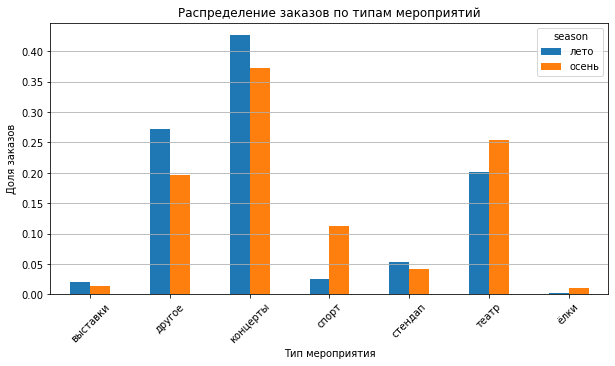

In [82]:
# Строим диаграмму распределения долей заказов по типам мероприятий
event_type_pivot.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Распределение заказов по типам мероприятий')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля заказов')
plt.xticks(rotation=45)

plt.grid(axis='y')

plt.show()

Концерты остаются самой популярной категорией мероприятий как летом, так и осенью, однако их доля снизилась с **42,6%** до **37,2%**.

Наиболее заметный рост наблюдается у театральных постановок — их доля увеличилась с **20,1%** до **25,3%**. Существенно выросла и доля спортивных мероприятий — с **2,5%** до **11,2%**, что свидетельствует об увеличении интереса пользователей к данной категории осенью.

Одновременно снизилась доля мероприятий категории «другое» (с **27,2%** до **19,7%**), а также стендапа и выставок. Несмотря на рост популярности отдельных категорий, концерты и театр остаются основными драйверами пользовательского спроса.

<a id="step-3-3"></a>
### Анализ распределения заказов по типам устройств

In [83]:
# Рассчитываем количество заказов по сезонам и типам устройств
device_share = (data.groupby(['season', 'device_type_canonical']).agg(orders_count=('order_id', 'count')).reset_index())

In [84]:
# Рассчитываем долю каждого типа устройства внутри сезона
device_share['share'] = (device_share.groupby('season')['orders_count'].transform(lambda x: x / x.sum()))

In [85]:
# Создаём сводную таблицу с долями заказов
device_pivot = (device_share.pivot(index='device_type_canonical',columns='season',values='share'))
device_pivot

season,лето,осень
device_type_canonical,,
desktop,0.193587,0.203452
mobile,0.806413,0.796548


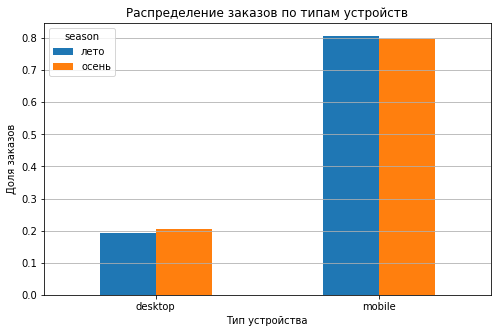

In [86]:
# Строим диаграмму распределения долей заказов по типам устройств
device_pivot.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Распределение заказов по типам устройств')
plt.xlabel('Тип устройства')
plt.ylabel('Доля заказов')
plt.xticks(rotation=0)

plt.grid(axis='y')

plt.show()

Мобильные устройства остаются основным способом оформления заказов в обоих сезонах. Летом на них приходилось **80,6%** всех заказов, а осенью — **79,7%**.

Доля заказов, оформленных со стационарных устройств, незначительно увеличилась — с **19,4%** летом до **20,3%** осенью. Существенных изменений в структуре используемых устройств не наблюдается, что свидетельствует о стабильном поведении пользователей независимо от сезона.

<a id="step-3-4"></a>
### Анализ распределения заказов по возрастным ограничениям

In [87]:
# Рассчитываем количество заказов по сезонам и возрастным ограничениям
age_share = (data.groupby(['season', 'age_limit']).agg(orders_count=('order_id', 'count')).reset_index())

In [88]:
# Рассчитываем долю каждого возрастного ограничения внутри сезона
age_share['share'] = (age_share.groupby('season')['orders_count'].transform(lambda x: x / x.sum()))

In [89]:
# Создаём сводную таблицу с долями заказов
age_pivot = (age_share.pivot(index='age_limit',columns='season',values='share'))
age_pivot

season,лето,осень
age_limit,,
0,0.179701,0.236249
6,0.181951,0.176291
12,0.205299,0.220761
16,0.283404,0.262283
18,0.149644,0.104416


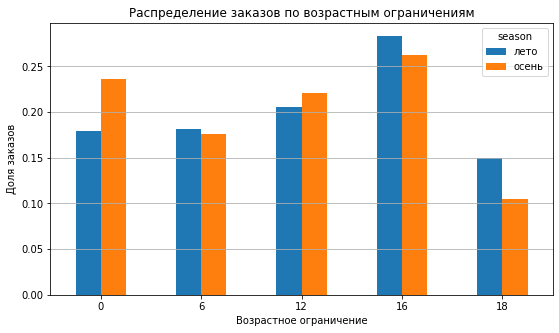

In [90]:
# Строим диаграмму распределения долей заказов по возрастным ограничениям
age_pivot.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Распределение заказов по возрастным ограничениям')
plt.xlabel('Возрастное ограничение')
plt.ylabel('Доля заказов')
plt.xticks(rotation=0)

plt.grid(axis='y')

plt.show()

Наибольшую долю заказов в обоих сезонах занимают мероприятия с возрастным ограничением **16+**, однако осенью их доля снизилась с **28,3%** до **26,2%**.

При этом увеличилась доля мероприятий без возрастных ограничений (**0+**) — с **18,0%** до **23,6%**, а также мероприятий категории **12+**. Напротив, доля мероприятий с ограничением **18+** сократилась с **15,0%** до **10,4%**.

Полученные результаты свидетельствуют о смещении пользовательского спроса осенью в сторону мероприятий, ориентированных на более широкую аудиторию.

<a id="step-3-5"></a>
### Анализ средней выручки с продажи одного билета по типам мероприятий

In [91]:
# Рассчитываем среднюю выручку с одного билета по сезонам и типам мероприятий
ticket_revenue = (data.groupby(['season', 'event_type_main']).agg(avg_revenue=('one_ticket_revenue_rub', 'mean')).reset_index())

In [92]:
# Создаём сводную таблицу со средней выручкой
ticket_revenue_pivot = (ticket_revenue.pivot(index='event_type_main',columns='season',values='avg_revenue'))
ticket_revenue_pivot

season,лето,осень
event_type_main,,
выставки,86.416197,90.603609
другое,77.433968,76.115333
концерты,304.717077,268.084074
спорт,50.761831,49.969733
стендап,218.518107,231.124973
театр,214.126334,175.969508
ёлки,271.436177,229.585590


In [93]:
# Рассчитываем относительное изменение средней выручки осенью по сравнению с летом
ticket_revenue_pivot['change_percent'] = ((ticket_revenue_pivot['осень'] - ticket_revenue_pivot['лето'])
    / ticket_revenue_pivot['лето'] * 100)
ticket_revenue_pivot

season,лето,осень,change_percent
event_type_main,,,
выставки,86.416197,90.603609,4.845633
другое,77.433968,76.115333,-1.702914
концерты,304.717077,268.084074,-12.021972
спорт,50.761831,49.969733,-1.560421
стендап,218.518107,231.124973,5.769255
театр,214.126334,175.969508,-17.819773
ёлки,271.436177,229.585590,-15.418205


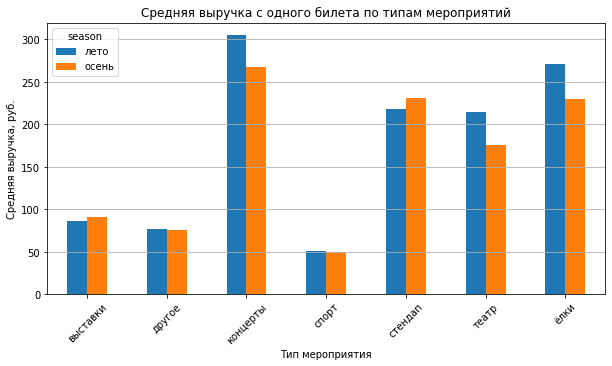

In [94]:
# Строим диаграмму средней выручки с одного билета по типам мероприятий
ticket_revenue_pivot[['лето', 'осень']].plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Средняя выручка с одного билета по типам мероприятий')
plt.xlabel('Тип мероприятия')
plt.ylabel('Средняя выручка, руб.')
plt.xticks(rotation=45)

plt.grid(axis='y')

plt.show()

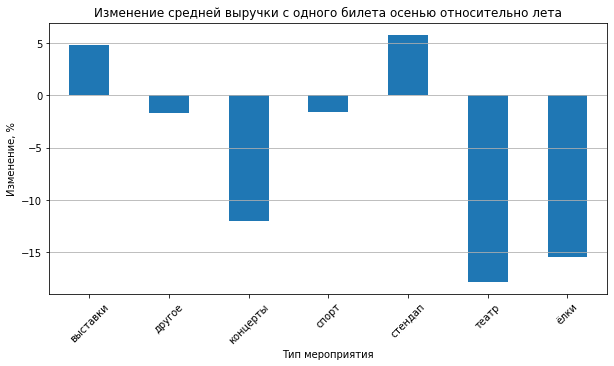

In [95]:
# Строим диаграмму относительного изменения средней выручки
ticket_revenue_pivot['change_percent'].plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Изменение средней выручки с одного билета осенью относительно лета')
plt.xlabel('Тип мероприятия')
plt.ylabel('Изменение, %')
plt.xticks(rotation=45)

plt.grid(axis='y')

plt.show()

Исследование показало выраженную сезонность пользовательского спроса. С июня по октябрь количество заказов последовательно увеличивалось, а максимальное значение было зафиксировано в октябре.

Структура спроса по типам мероприятий изменилась. Несмотря на то, что концерты сохранили лидерство по количеству заказов, их доля осенью снизилась. Одновременно увеличилась популярность театральных постановок и спортивных мероприятий, тогда как доля категории «другое», стендапа и выставок уменьшилась.

Анализ возрастных ограничений показал рост доли мероприятий без возрастных ограничений (0+) и категории 12+, при одновременном снижении доли мероприятий 16+ и особенно 18+, что свидетельствует о смещении интереса пользователей в сторону мероприятий для более широкой аудитории.

Распределение заказов по типам устройств практически не изменилось. Основная часть заказов в обоих сезонах оформлялась с мобильных устройств, а доля заказов с компьютеров увеличилась лишь незначительно.

Средняя выручка с продажи одного билета изменилась неоднозначно. Рост средней стоимости наблюдается только у выставок и стендапа, тогда как для большинства категорий, особенно театра, ёлок и концертов, она снизилась. Это может свидетельствовать о смещении пользовательского спроса в сторону более доступных мероприятий или изменении ценовой политики организаторов.

<a id="step-3-6"></a>
### Осенняя активность пользователей

In [96]:
# Отбираем данные только за осенний период
autumn_data = data[data['season'] == 'осень'].copy()

In [97]:
# Проверяем размер датасета после отбора осенних заказов
autumn_data.shape

(168585, 30)

In [98]:
# Рассчитываем ежедневные показатели пользовательской активности
daily_metrics = (autumn_data.groupby('created_dt_msk').agg(
        orders_count=('order_id', 'count'),
        dau=('user_id', 'nunique'),
        avg_ticket_price=('one_ticket_revenue_rub', 'mean')
    ).reset_index())

In [99]:
# Рассчитываем среднее количество заказов на одного пользователя
daily_metrics['orders_per_user'] = (daily_metrics['orders_count'] / daily_metrics['dau'])

In [100]:
# Просматриваем первые строки рассчитанных ежедневных метрик
daily_metrics.head()

,created_dt_msk,orders_count,dau,avg_ticket_price,orders_per_user
0,2024-09-01,1327,564,200.168708,2.352837
1,2024-09-02,1380,574,189.464640,2.404181
2,2024-09-03,5111,778,80.130097,6.569409
3,2024-09-04,1772,685,177.785850,2.586861
4,2024-09-05,1944,739,189.510156,2.630582


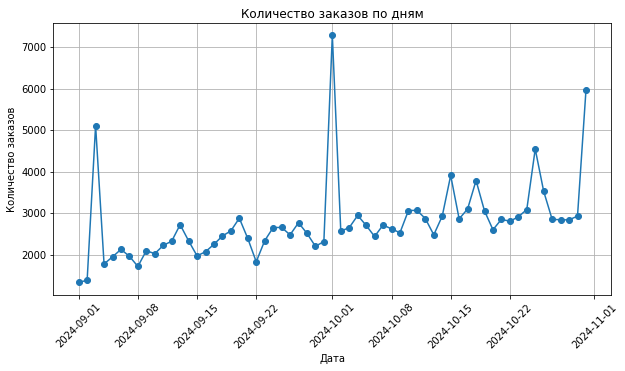

In [101]:
# Строим график количества заказов по дням
plt.figure(figsize=(10, 5))

plt.plot(
    daily_metrics['created_dt_msk'],
    daily_metrics['orders_count'],
    marker='o'
)

plt.title('Количество заказов по дням')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

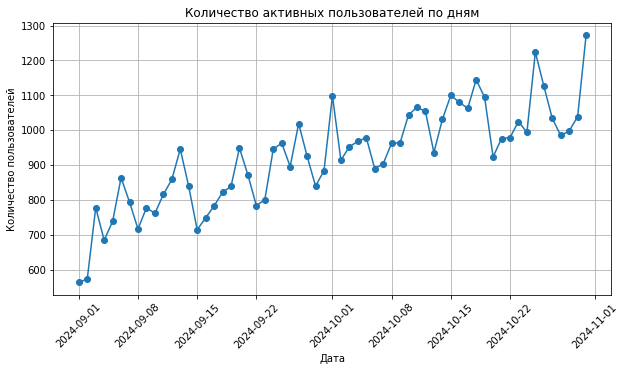

In [102]:
# Строим график количества активных пользователей по дням
plt.figure(figsize=(10, 5))

plt.plot(
    daily_metrics['created_dt_msk'],
    daily_metrics['dau'],
    marker='o'
)

plt.title('Количество активных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

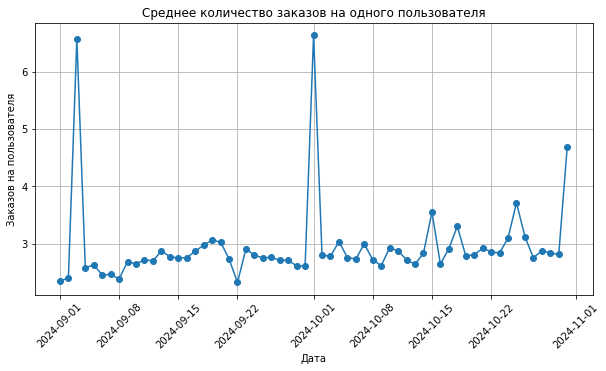

In [103]:
# Строим график среднего количества заказов на одного пользователя
plt.figure(figsize=(10, 5))

plt.plot(
    daily_metrics['created_dt_msk'],
    daily_metrics['orders_per_user'],
    marker='o'
)

plt.title('Среднее количество заказов на одного пользователя')
plt.xlabel('Дата')
plt.ylabel('Заказов на пользователя')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

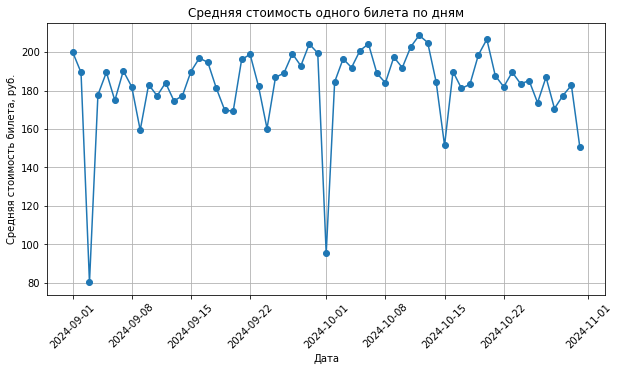

In [104]:
# Строим график средней стоимости одного билета по дням
plt.figure(figsize=(10, 5))

plt.plot(
    daily_metrics['created_dt_msk'],
    daily_metrics['avg_ticket_price'],
    marker='o'
)

plt.title('Средняя стоимость одного билета по дням')
plt.xlabel('Дата')
plt.ylabel('Средняя стоимость билета, руб.')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

В течение осени наблюдается общий рост пользовательской активности. Количество заказов и число активных пользователей постепенно увеличиваются от сентября к концу октября, что свидетельствует о повышении спроса на сервис.

Среднее количество заказов на одного пользователя большую часть периода остаётся стабильным и составляет около **2,5–3 заказов**. При этом в отдельные дни наблюдаются резкие всплески показателя, вызванные значительным увеличением количества заказов при относительно небольшом росте числа пользователей.

Средняя стоимость одного билета в основном находится в диапазоне **170–200 рублей**, однако в отдельные даты фиксируются заметные снижения. Эти отклонения могут быть связаны с проведением акций, изменением структуры приобретаемых мероприятий или увеличением доли более дешёвых билетов.

В целом рост общего числа заказов осенью обеспечивается преимущественно увеличением количества активных пользователей, тогда как среднее число заказов на одного пользователя остаётся практически неизменным.

<a id="step-3-7"></a>
### Анализ недельной цикличности

In [105]:
# Создаём столбец с названием дня недели
daily_metrics['weekday'] = daily_metrics['created_dt_msk'].dt.day_name()

In [106]:
# Заменяем английские названия дней недели на русские
daily_metrics['weekday'] = daily_metrics['weekday'].replace({
    'Monday': 'Понедельник',
    'Tuesday': 'Вторник',
    'Wednesday': 'Среда',
    'Thursday': 'Четверг',
    'Friday': 'Пятница',
    'Saturday': 'Суббота',
    'Sunday': 'Воскресенье'
})

In [107]:
# Создаём столбец с типом дня
daily_metrics['day_type'] = np.where(daily_metrics['weekday'].isin(['Суббота', 'Воскресенье']),'Выходной','Будний')

In [108]:
# Рассчитываем средние показатели по будним и выходным дням
week_stats = (daily_metrics.groupby('day_type').agg(
        avg_orders=('orders_count', 'mean'),
        avg_dau=('dau', 'mean'),
        avg_orders_per_user=('orders_per_user', 'mean'),
        avg_ticket_price=('avg_ticket_price', 'mean')))
week_stats

,avg_orders,avg_dau,avg_orders_per_user,avg_ticket_price
day_type,,,,
Будний,2906.000000,937.227273,3.065501,178.469235
Выходной,2395.352941,887.588235,2.675113,195.100543


Анализ недельной цикличности показал, что в будние дни пользователи проявляют более высокую активность. В среднем за будний день оформляется около **2906 заказов**, тогда как в выходные — **2395 заказов**. Аналогичная картина наблюдается и по количеству активных пользователей: **937** в будние дни против **888** в выходные.

Среднее количество заказов на одного пользователя также выше в будние дни (**3,07** против **2,68**), что свидетельствует о более высокой интенсивности использования сервиса.

При этом средняя стоимость одного билета в выходные выше (**195,1 руб.**) по сравнению с будними днями (**178,5 руб.**). Это может быть связано с повышенным спросом на более дорогие мероприятия или изменением структуры приобретаемых билетов в выходные дни.

<a id="step-3-8"></a>
### Популярные события и партнёры

In [109]:
# Рассчитываем количество уникальных мероприятий и заказов по регионам
region_stats = (data.groupby('region_name').agg(unique_events=('event_id', 'nunique'),orders_count=('order_id', 'count'))
    .sort_values('orders_count', ascending=False)
    .reset_index())
region_stats.head(10)

,region_name,unique_events,orders_count
0,Каменевский регион,5935,89665
1,Североярская область,3800,43738
2,Широковская область,1232,16169
3,Медовская область,504,13892
4,Озернинский край,349,10348
5,Светополянский округ,1075,7502
6,Малиновоярский округ,165,6314
7,Солнечноземская область,522,6278
8,Речиновская область,702,6267
9,Яблоневская область,535,6123


In [110]:
# Рассчитываем долю заказов каждого региона
region_stats['orders_share'] = (region_stats['orders_count'] /region_stats['orders_count'].sum())

In [111]:
# Рассчитываем долю уникальных мероприятий каждого региона
region_stats['events_share'] = (region_stats['unique_events'] /region_stats['unique_events'].sum())

In [112]:
# Выводим 10 регионов с наибольшим количеством заказов
region_stats.head(10)

,region_name,unique_events,orders_count,orders_share,events_share
0,Каменевский регион,5935,89665,0.311668,0.265441
1,Североярская область,3800,43738,0.152030,0.169954
2,Широковская область,1232,16169,0.056202,0.055101
3,Медовская область,504,13892,0.048287,0.022541
4,Озернинский край,349,10348,0.035969,0.015609
5,Светополянский округ,1075,7502,0.026076,0.048079
6,Малиновоярский округ,165,6314,0.021947,0.007380
7,Солнечноземская область,522,6278,0.021822,0.023346
8,Речиновская область,702,6267,0.021784,0.031397
9,Яблоневская область,535,6123,0.021283,0.023928


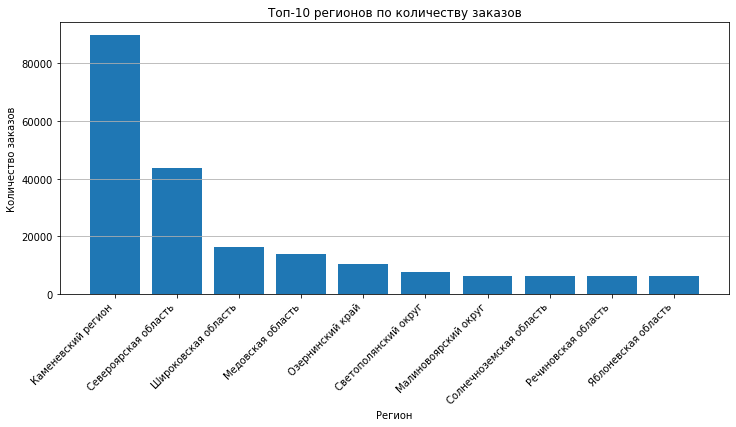

In [113]:
# Строим диаграмму количества заказов по регионам
plt.figure(figsize=(12, 5))

plt.bar(
    region_stats.head(10)['region_name'],
    region_stats.head(10)['orders_count']
)

plt.title('Топ-10 регионов по количеству заказов')
plt.xlabel('Регион')
plt.ylabel('Количество заказов')

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y')

plt.show()

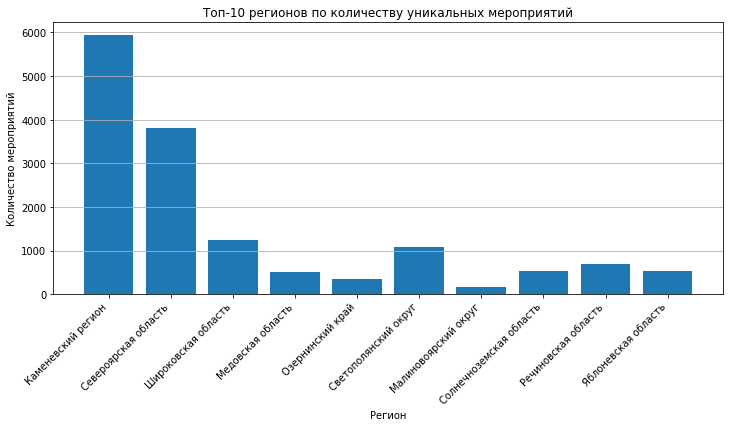

In [114]:
# Строим диаграмму количества уникальных мероприятий по регионам
plt.figure(figsize=(12, 5))

plt.bar(
    region_stats.head(10)['region_name'],
    region_stats.head(10)['unique_events']
)

plt.title('Топ-10 регионов по количеству уникальных мероприятий')
plt.xlabel('Регион')
plt.ylabel('Количество мероприятий')

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y')

plt.show()

Наиболее выраженным лидером является **Каменевский регион**: на него приходится **89 665 заказов**, или около **31,2%** от общего количества. В регионе также представлено наибольшее число уникальных мероприятий — **5 935**, что составляет около **26,5%** от общего количества событий.

Второе место занимает **Североярская область** с **43 738 заказами** и **3 800 уникальными мероприятиями**. На два ведущих региона суммарно приходится более **46%** всех заказов, что указывает на высокую концентрацию спроса.

Большинство остальных регионов заметно уступают лидерам как по числу заказов, так и по разнообразию мероприятий. В целом наблюдается связь между количеством представленных событий и объёмом заказов: регионы с более широким выбором мероприятий, как правило, привлекают больше пользователей.

При этом зависимость не является полностью прямой. Например, **Светополянский округ** занимает высокую позицию по количеству уникальных мероприятий, но уступает нескольким регионам по числу заказов. Это может указывать на различия в востребованности событий, размере аудитории или эффективности продвижения мероприятий.

Таким образом, явными лидерами по разнообразию событий и пользовательскому спросу являются Каменевский регион и Североярская область, тогда как распределение заказов между остальными регионами более равномерно.

<a id="step-3-9"></a>
### Анализ билетных операторов

In [115]:
# Рассчитываем количество заказов по билетным операторам
service_stats = (data.groupby('service_name').agg(orders_count=('order_id', 'count'),avg_revenue=('revenue_rub', 'mean'))
    .sort_values('orders_count', ascending=False)
    .reset_index())
service_stats.head(10)

,service_name,orders_count,avg_revenue
0,Билеты без проблем,62832,386.035007
1,Лови билет!,40800,408.586605
2,Билеты в руки,40281,327.557157
3,Мой билет,34440,640.022202
4,Облачко,26402,704.060823
5,Лучшие билеты,17740,153.409863
6,Весь в билетах,16410,1005.159612
7,Прачечная,10222,464.371992
8,Край билетов,6109,1048.565925
9,Тебе билет!,5177,565.749027


In [116]:
# Рассчитываем долю заказов каждого билетного оператора
service_stats['orders_share'] = (service_stats['orders_count']/ service_stats['orders_count'].sum())
service_stats.head(10)

,service_name,orders_count,avg_revenue,orders_share
0,Билеты без проблем,62832,386.035007,0.218399
1,Лови билет!,40800,408.586605,0.141817
2,Билеты в руки,40281,327.557157,0.140013
3,Мой билет,34440,640.022202,0.119711
4,Облачко,26402,704.060823,0.091771
5,Лучшие билеты,17740,153.409863,0.061663
6,Весь в билетах,16410,1005.159612,0.057040
7,Прачечная,10222,464.371992,0.035531
8,Край билетов,6109,1048.565925,0.021234
9,Тебе билет!,5177,565.749027,0.017995


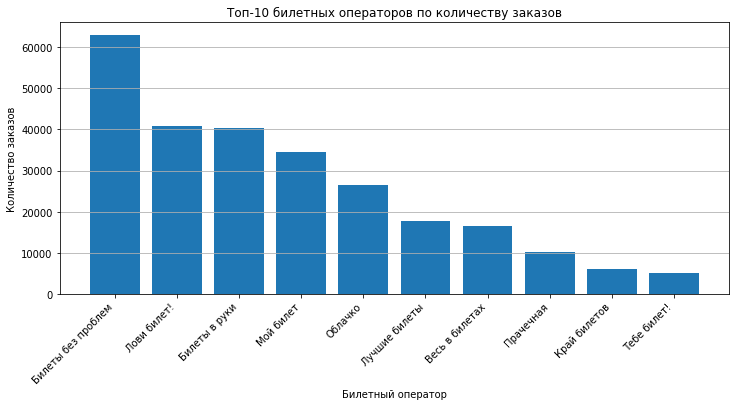

In [117]:
# Строим диаграмму количества заказов по билетным операторам
plt.figure(figsize=(12, 5))

plt.bar(
    service_stats.head(10)['service_name'],
    service_stats.head(10)['orders_count']
)

plt.title('Топ-10 билетных операторов по количеству заказов')
plt.xlabel('Билетный оператор')
plt.ylabel('Количество заказов')

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y')

plt.show()

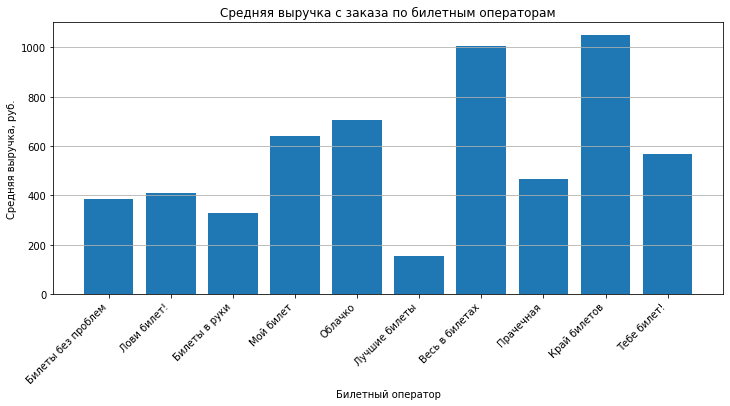

In [118]:
# Строим диаграмму средней выручки с заказа
plt.figure(figsize=(12, 5))

plt.bar(
    service_stats.head(10)['service_name'],
    service_stats.head(10)['avg_revenue']
)

plt.title('Средняя выручка с заказа по билетным операторам')
plt.xlabel('Билетный оператор')
plt.ylabel('Средняя выручка, руб.')

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y')

plt.show()

Наибольшее количество заказов приходится на оператора **«Билеты без проблем»** — **62 832 заказа**, или около **21,8%** всех заказов. Далее следуют **«Лови билет!»** (**40 800 заказов**) и **«Билеты в руки»** (**40 281 заказ**). Совокупно три крупнейших оператора обеспечивают почти **50%** общего объёма заказов.

При сравнении средней выручки с одного заказа картина существенно отличается. Лидерами становятся **«Край билетов»** (≈ **1049 руб.**) и **«Весь в билетах»** (≈ **1005 руб.**), несмотря на относительно небольшое количество заказов. Это может свидетельствовать о специализации данных операторов на более дорогих мероприятиях или заказах с большим количеством билетов.

В то же время оператор **«Лучшие билеты»** демонстрирует одну из самых низких средних выручек — около **153 руб.** за заказ, хотя входит в десятку по количеству оформленных заказов. Это указывает на преобладание недорогих заказов или продаж билетов по низкой стоимости.

Таким образом, между популярностью билетного оператора и средней выручкой с заказа не наблюдается прямой зависимости: операторы с наибольшим количеством заказов не являются лидерами по размеру среднего чека, а самые высокие значения средней выручки характерны для операторов с относительно небольшой долей рынка.

<a id="step-4"></a>
##  Статистический анализ данных
<a id="step-4-1"></a>
### Изучение данных для проверки первой гипотезы

In [119]:
# Создаём выборку пользователей мобильных устройств
mobile = autumn_data[autumn_data['device_type_canonical'] == 'mobile']

In [120]:
# Создаём выборку пользователей стационарных устройств
desktop = autumn_data[autumn_data['device_type_canonical'] == 'desktop']

In [121]:
# Рассчитываем количество заказов каждого пользователя
mobile_orders = mobile.groupby('user_id')['order_id'].count()
desktop_orders = desktop.groupby('user_id')['order_id'].count()

In [122]:
# Выводим статистические показатели для мобильных устройств
mobile_orders.describe()

count    14188.000000
mean         9.464759
std         68.033254
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       4331.000000
Name: order_id, dtype: float64

In [123]:
# Выводим статистические показатели для стационарных устройств
desktop_orders.describe()

count    4868.000000
mean        7.045809
std        35.987352
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max      1502.000000
Name: order_id, dtype: float64

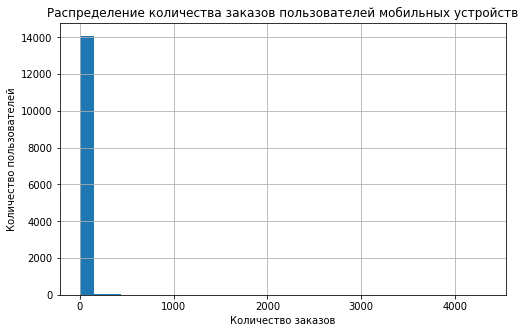

In [124]:
# Строим гистограмму распределения количества заказов пользователей мобильных устройств
mobile_orders.hist(bins=30, figsize=(8, 5))

plt.title('Распределение количества заказов пользователей мобильных устройств')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')

plt.show()

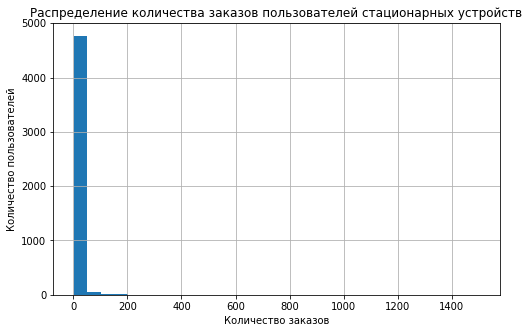

In [125]:
# Строим гистограмму распределения количества заказов пользователей стационарных устройств
desktop_orders.hist(bins=30, figsize=(8, 5))

plt.title('Распределение количества заказов пользователей стационарных устройств')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')

plt.show()

In [126]:
# Сравниваем дисперсии выборок
print('Дисперсия mobile:', mobile_orders.var())
print('Дисперсия desktop:', desktop_orders.var())

Дисперсия mobile: 4628.52367515864
Дисперсия desktop: 1295.0895386297705


Количество пользователей мобильных устройств (**14 188**) примерно в три раза превышает количество пользователей стационарных устройств (**4 868**).

Среднее число заказов на одного пользователя выше у мобильных устройств (**9,46**) по сравнению со стационарными (**7,05**). При этом медиана в обеих выборках составляет **2 заказа**, что говорит о сильной асимметрии распределений.

Гистограммы показывают, что распределения имеют выраженный правый хвост: большинство пользователей оформляют небольшое количество заказов, тогда как небольшая доля пользователей совершает очень большое число покупок. Максимальные значения достигают **4331** заказа для мобильных устройств и **1502** — для стационарных.

Дисперсии выборок также существенно различаются (**4628,52** против **1295,09**), поэтому при проверке гипотезы необходимо использовать t-критерий Уэлча, не предполагающий равенство дисперсий.

<a id="step-4-2"></a>
### Проверка первой гипотезы

**Сформулируем гипотезу:**

H0: среднее количество заказов на одного пользователя мобильного приложения меньше либо равно среднему количеству заказов пользователей стационарных устройств.

H1: среднее количество заказов на одного пользователя мобильного приложения больше среднего количества заказов пользователей стационарных устройств.

In [127]:
# Формулируем уровень статистической значимости
alpha = 0.05

# Проверяем гипотезу
results = stats.ttest_ind(
    mobile_orders,
    desktop_orders,
    equal_var=False,
    alternative='greater'
)

if results.pvalue <= alpha:
        print(f'Полученное значение p-value = {results.pvalue:.5f} меньше уровня значимости {alpha}. Отвергаем нулевую гипотезу.')
else:
        print(f'Полученное значение p-value = {results.pvalue:.5f} больше уровня значимости {alpha}. Не удалось отвергнуть нулевую гипотезу.')

Полученное значение p-value = 0.00084 меньше уровня значимости 0.05. Отвергаем нулевую гипотезу.


В результате проверки гипотезы получено значение **p-value = 0,00084**, что значительно меньше принятого уровня статистической значимости **0,05**.

Это позволяет отвергнуть нулевую гипотезу в пользу альтернативной. Следовательно, имеются статистически значимые основания утверждать, что **среднее количество заказов на одного пользователя мобильного приложения выше, чем у пользователей стационарных устройств**.

Полученный результат согласуется с описательной статистикой: пользователи мобильных устройств в среднем оформляют больше заказов, чем пользователи стационарных устройств.

<a id="step-4-3"></a>
### Изучение данных для проверки второй гипотезы

In [128]:
# Создаём выборку времени между заказами для мобильных устройств
mobile_days = autumn_data.loc[autumn_data['device_type_canonical'] == 'mobile','days_since_prev'].dropna()

In [129]:
# Создаём выборку времени между заказами для стационарных устройств
desktop_days = autumn_data.loc[autumn_data['device_type_canonical'] == 'desktop','days_since_prev'].dropna()

In [130]:
# Выводим статистические показатели для мобильных устройств
mobile_days.describe()

count    127303.000000
mean          3.778717
std          13.382397
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         148.000000
Name: days_since_prev, dtype: float64

In [131]:
# Выводим статистические показатели для стационарных устройств
desktop_days.describe()

count    32941.000000
mean         3.025470
std         12.096041
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        146.000000
Name: days_since_prev, dtype: float64

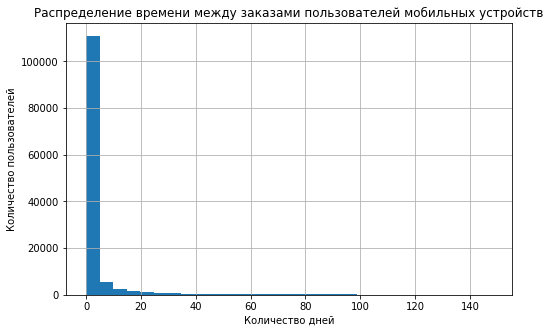

In [132]:
# Строим гистограмму распределения времени между заказами пользователей мобильных устройств
mobile_days.hist(bins=30, figsize=(8, 5))

plt.title('Распределение времени между заказами пользователей мобильных устройств')
plt.xlabel('Количество дней')
plt.ylabel('Количество пользователей')

plt.show()

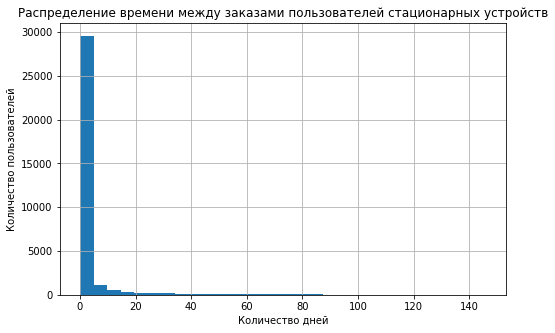

In [133]:
# Строим гистограмму распределения времени между заказами пользователей стационарных устройств
desktop_days.hist(bins=30, figsize=(8, 5))

plt.title('Распределение времени между заказами пользователей стационарных устройств')
plt.xlabel('Количество дней')
plt.ylabel('Количество пользователей')

plt.show()

In [134]:
# Сравниваем дисперсии выборок
print('Дисперсия mobile:', mobile_days.var())
print('Дисперсия desktop:', desktop_days.var())

Дисперсия mobile: 179.08853
Дисперсия desktop: 146.3142


Количество наблюдений для пользователей мобильных устройств составляет **127 303**, а для пользователей стационарных устройств — **32 941**.

Среднее время между заказами у пользователей мобильных устройств равно **3,78 дня**, тогда как у пользователей стационарных устройств — **3,03 дня**. При этом медианное значение в обеих выборках составляет **0 дней**, что свидетельствует о наличии большого числа повторных заказов в один и тот же день.

Гистограммы показывают, что распределения сильно смещены вправо: большинство пользователей оформляют повторные заказы в течение короткого времени, однако присутствуют отдельные наблюдения с длительными интервалами между покупками (до **148** и **146** дней соответственно).

Дисперсии выборок различаются (**179,09** против **146,31**), поэтому для проверки гипотезы целесообразно использовать t-критерий Уэлча, не предполагающий равенство дисперсий.

<a id="step-4-4"></a>
### Проверка второй гипотезы

**Сформулируем гипотезу:**


H0: Среднее время между заказами пользователей мобильных приложений равно среднему времени между заказами пользователей стационарных устройств.

H1: Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

In [135]:
# Формулируем уровень статистической значимости
alpha = 0.05

# Проверяем гипотезу
results = stats.ttest_ind(
    mobile_days,
    desktop_days,
    equal_var=False,
    alternative='greater'
)

if results.pvalue <= alpha:
    print(f'Полученное значение p-value = {results.pvalue:.5f} меньше уровня значимости {alpha}. Отвергаем нулевую гипотезу.')
else:
    print(f'Полученное значение p-value = {results.pvalue:.5f} больше уровня значимости {alpha}. Не удалось отвергнуть нулевую гипотезу.')

Полученное значение p-value = 0.00000 меньше уровня значимости 0.05. Отвергаем нулевую гипотезу.


По результатам проверки гипотезы получено значение **p-value < 0,00001**, что значительно меньше уровня статистической значимости **0,05**. Следовательно, нулевая гипотеза отвергается.

Полученные результаты свидетельствуют о том, что среднее время между заказами пользователей мобильных устройств статистически значимо больше, чем у пользователей стационарных устройств.

Таким образом, результаты статистического теста подтверждают выдвинутую альтернативную гипотезу.

<a id="step-5"></a>
## Общий вывод

В ходе исследования были проанализированы данные о заказах билетов, мероприятиях и курсах валют за период с июня по октябрь 2024 года. После предварительной обработки данных были устранены выбросы по выручке, удалены записи без информации о мероприятиях, проверены пропуски, дубликаты и типы данных, а выручка была приведена к единой валюте — рублям. Для анализа пользовательской активности использовались данные осеннего периода (сентябрь–октябрь 2024 года).

В результате анализа были выявлены следующие закономерности:

- На протяжении исследуемого периода количество заказов стабильно росло: с июня по октябрь число оформленных заказов увеличилось почти в три раза. Наибольшая активность пользователей наблюдалась в октябре.
- Наиболее востребованным типом мероприятий оказались концерты — как летом, так и осенью они занимали наибольшую долю всех заказов. Второе место занимали театральные мероприятия, а наименее популярными были выставки и новогодние ёлки.
- Средняя стоимость одного билета различалась между категориями мероприятий. Самыми дорогими оказались билеты на концерты, ёлки и стендап, тогда как наиболее низкая стоимость наблюдалась у спортивных мероприятий и выставок. Осенью средняя стоимость билетов снизилась для большинства категорий, за исключением выставок и стендапа.
- Основная часть заказов оформлялась с мобильных устройств — их доля на протяжении всего периода составляла около 80% и практически не менялась.
- Наибольшая доля заказов приходилась на мероприятия с возрастным ограничением 16+, при этом осенью несколько увеличилась доля мероприятий без возрастных ограничений.
- Пользовательская активность в осенний период постепенно росла: увеличивалось как количество заказов, так и число активных пользователей. В будние дни пользователи оформляли больше заказов, тогда как в выходные средняя стоимость одного билета была выше.
- Среди регионов выделяются явные лидеры. Каменевский регион значительно опережает остальные как по количеству заказов, так и по числу уникальных мероприятий. Аналогичная концентрация наблюдается и среди билетных операторов — несколько крупнейших партнёров обеспечивают существенную часть всех продаж.

Проверка статистических гипотез показала:

- Среднее количество заказов на одного пользователя мобильного приложения статистически значимо выше, чем у пользователей стационарных устройств (p-value < 0.05). Это позволяет сделать вывод о более высокой активности пользователей мобильных устройств.
- Среднее время между заказами у пользователей мобильных устройств также статистически значимо больше, чем у пользователей стационарных устройств (p-value < 0.05). Полученные результаты подтверждают выдвинутую гипотезу.

По результатам исследования можно рекомендовать:

- продолжать развитие мобильного приложения, поскольку именно мобильные пользователи обеспечивают основную часть заказов и демонстрируют более высокую активность;
- уделить особое внимание крупнейшим регионам и билетным операторам, которые формируют значительную долю продаж;
- поддерживать наиболее популярные категории мероприятий (прежде всего концерты и театры), одновременно анализируя причины снижения средней стоимости билетов в отдельных категориях;
- дополнительно исследовать причины резких всплесков пользовательской активности в отдельные даты, чтобы использовать подобные факторы при планировании маркетинговых кампаний и продвижения мероприятий.